In [1]:
! pip install "pandas<3.0.0"

In [2]:
import pandas as pd

In [3]:
!pip install neuralprophet

In [4]:
from neuralprophet import NeuralProphet

In [5]:
!pip install yfinance

In [6]:
import yfinance as yf

In [7]:
nvidia = yf.download("NVDA", start="2000-01-1", end="2026-04-01")

[*********************100%***********************]  1 of 1 completed


In [8]:
nvidia.columns = nvidia.columns.get_level_values(0)

In [9]:
nvidia

Price,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000
...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700


In [10]:
nvidia.columns.name = None

In [11]:
nvidia

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000
...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700


In [12]:
nvidia.reset_index(inplace=True)

In [13]:
nvidia

,Date,Close,High,Low,Open,Volume
0,2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000
1,2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000
2,2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000
3,2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000
4,2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000
...,...,...,...,...,...,...
6595,2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100
6596,2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200
6597,2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700
6598,2026-03-30,164.793320,169.063558,163.895378,168.395088,185627000


In [14]:
sia = pd.read_csv("Semiconductors.csv", sep=";", decimal=",")
sia.shape

(50, 2)

In [15]:
sia["Date"]=pd.to_datetime(sia["Date"])

In [16]:
sia

,Date,Value
0,2026-06-30,53.250
1,2026-05-31,49.580
2,2026-04-30,41.790
3,2026-03-31,40.600
4,2026-02-28,36.200
5,2026-01-31,24.630
6,2025-12-31,28.690
7,2025-11-30,25.940
8,2025-10-31,23.590
9,2025-09-30,25.150


In [17]:
nvidia.set_index("Date",inplace=True)

In [18]:
nvidia

,Close,High,Low,Open,Volume
Date,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000
...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700


In [19]:
sia.set_index("Date",inplace=True)

In [20]:
nvidia["Close_l"]=nvidia["Close"].shift(1)
nvidia["Close_2"]=nvidia["Close"].shift(2)

In [21]:
nvidia

,Close,High,Low,Open,Volume,Close_l,Close_2
Date,,,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000,NaN,NaN
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000,0.089206,NaN
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000,0.086825,0.089206
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000,0.083966,0.086825
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000,0.078487,0.083966
...,...,...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100,174.800446,175.239441
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200,178.272507,174.800446
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700,170.849487,178.272507


In [22]:
sia["Value_l"]=sia["Value"].shift(1)
sia["Value_2"]=sia["Value"].shift(2)

In [23]:
sia

,Value,Value_l,Value_2
Date,,,
2026-06-30,53.250,NaN,NaN
2026-05-31,49.580,53.250,NaN
2026-04-30,41.790,49.580,53.250
2026-03-31,40.600,41.790,49.580
2026-02-28,36.200,40.600,41.790
2026-01-31,24.630,36.200,40.600
2025-12-31,28.690,24.630,36.200
2025-11-30,25.940,28.690,24.630
2025-10-31,23.590,25.940,28.690


In [24]:
nvidia["Rolling_mean_3"]=nvidia["Close"].rolling(3).mean()
nvidia["Rolling_std_3"]=nvidia["Close"].rolling(3).std()

In [25]:
sia["Rolling_mean_3"]=sia["Value"].rolling(3).mean()
sia["Rolling_std_3"]=sia["Value"].rolling(3).std()
sia

,Value,Value_l,Value_2,Rolling_mean_3,Rolling_std_3
Date,,,,,
2026-06-30,53.250,NaN,NaN,NaN,NaN
2026-05-31,49.580,53.250,NaN,NaN,NaN
2026-04-30,41.790,49.580,53.250,48.206667,5.852131
2026-03-31,40.600,41.790,49.580,43.990000,4.877510
2026-02-28,36.200,40.600,41.790,39.530000,2.944605
2026-01-31,24.630,36.200,40.600,33.810000,8.248897
2025-12-31,28.690,24.630,36.200,29.840000,5.870102
2025-11-30,25.940,28.690,24.630,26.420000,2.072125
2025-10-31,23.590,25.940,28.690,26.073333,2.552613


In [26]:
nvidia["Spanding_mean"]=nvidia["Close"].expanding().mean()
nvidia

,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3,Rolling_std_3,Spanding_mean
Date,,,,,,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000,NaN,NaN,NaN,NaN,0.089206
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000,0.089206,NaN,NaN,NaN,0.088016
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000,0.086825,0.089206,0.086666,0.002624,0.086666
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000,0.083966,0.086825,0.083093,0.004237,0.084621
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000,0.078487,0.083966,0.080750,0.002861,0.083656
...,...,...,...,...,...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100,174.800446,175.239441,176.104131,1.890653,15.497054
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200,178.272507,174.800446,174.640813,3.714083,15.520603
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700,170.849487,178.272507,172.086655,5.669428,15.543582


In [27]:
sia["Spanding_mean"]=sia["Value"].expanding().mean()
sia

,Value,Value_l,Value_2,Rolling_mean_3,Rolling_std_3,Spanding_mean
Date,,,,,,
2026-06-30,53.250,NaN,NaN,NaN,NaN,53.250000
2026-05-31,49.580,53.250,NaN,NaN,NaN,51.415000
2026-04-30,41.790,49.580,53.250,48.206667,5.852131,48.206667
2026-03-31,40.600,41.790,49.580,43.990000,4.877510,46.305000
2026-02-28,36.200,40.600,41.790,39.530000,2.944605,44.284000
2026-01-31,24.630,36.200,40.600,33.810000,8.248897,41.008333
2025-12-31,28.690,24.630,36.200,29.840000,5.870102,39.248571
2025-11-30,25.940,28.690,24.630,26.420000,2.072125,37.585000
2025-10-31,23.590,25.940,28.690,26.073333,2.552613,36.030000


In [28]:
nvidia["return"]=nvidia['Close'].pct_change()
sia["return"]=sia['Value'].pct_change()
nvidia

,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3,Rolling_std_3,Spanding_mean,return
Date,,,,,,,,,,,
2000-01-03,0.089206,0.090755,0.084085,0.090041,300912000,NaN,NaN,NaN,NaN,0.089206,NaN
2000-01-04,0.086825,0.087897,0.082418,0.087658,300480000,0.089206,NaN,NaN,NaN,0.088016,-0.026701
2000-01-05,0.083966,0.085753,0.082775,0.084324,188352000,0.086825,0.089206,0.086666,0.002624,0.086666,-0.032921
2000-01-06,0.078487,0.083966,0.075272,0.083966,120480000,0.083966,0.086825,0.083093,0.004237,0.084621,-0.065253
2000-01-07,0.079798,0.080631,0.076939,0.078130,71184000,0.078487,0.083966,0.080750,0.002861,0.083656,0.016701
...,...,...,...,...,...,...,...,...,...,...,...
2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100,174.800446,175.239441,176.104131,1.890653,15.497054,0.019863
2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200,178.272507,174.800446,174.640813,3.714083,15.520603,-0.041639
2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700,170.849487,178.272507,172.086655,5.669428,15.543582,-0.021724


In [29]:
nvidia["Year"]=nvidia.index.year
nvidia["Month"]=nvidia.index.month
sia["Year"]=sia.index.year
sia["Month"]=sia.index.month

In [30]:
nvidia["YM"]=nvidia.index.to_period("M")
sia["YM"]=sia.index.to_period("M")

In [31]:
sia

,Value,Value_l,Value_2,Rolling_mean_3,Rolling_std_3,Spanding_mean,return,Year,Month,YM
Date,,,,,,,,,,
2026-06-30,53.250,NaN,NaN,NaN,NaN,53.250000,NaN,2026,6,2026-06
2026-05-31,49.580,53.250,NaN,NaN,NaN,51.415000,-0.068920,2026,5,2026-05
2026-04-30,41.790,49.580,53.250,48.206667,5.852131,48.206667,-0.157120,2026,4,2026-04
2026-03-31,40.600,41.790,49.580,43.990000,4.877510,46.305000,-0.028476,2026,3,2026-03
2026-02-28,36.200,40.600,41.790,39.530000,2.944605,44.284000,-0.108374,2026,2,2026-02
2026-01-31,24.630,36.200,40.600,33.810000,8.248897,41.008333,-0.319613,2026,1,2026-01
2025-12-31,28.690,24.630,36.200,29.840000,5.870102,39.248571,0.164840,2025,12,2025-12
2025-11-30,25.940,28.690,24.630,26.420000,2.072125,37.585000,-0.095852,2025,11,2025-11
2025-10-31,23.590,25.940,28.690,26.073333,2.552613,36.030000,-0.090594,2025,10,2025-10


In [32]:
final = pd.merge(nvidia.reset_index(), sia.reset_index(),on="YM",how="inner")

In [33]:
final

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,Date_y,Value,Value_l,Value_2,Rolling_mean_3_y,Rolling_std_3_y,Spanding_mean_y,return_y,Year_y,Month_y
0,2022-05-02,19.453033,19.493864,18.315709,18.465094,572049000,18.471077,19.701015,19.208375,0.650446,...,2022-05-31,12.61,12.10,10.80,11.836667,0.933292,18.541,0.042149,2022,5
1,2022-05-03,19.521749,19.743838,19.054670,19.320577,475751000,19.453033,18.471077,19.148620,0.587775,...,2022-05-31,12.61,12.10,10.80,11.836667,0.933292,18.541,0.042149,2022,5
2,2022-05-04,20.250757,20.316487,18.674237,19.841440,648855000,19.521749,19.453033,19.741847,0.442067,...,2022-05-31,12.61,12.10,10.80,11.836667,0.933292,18.541,0.042149,2022,5
3,2022-05-05,18.766859,19.843433,18.424267,19.785672,626331000,20.250757,19.521749,19.513122,0.741987,...,2022-05-31,12.61,12.10,10.80,11.836667,0.933292,18.541,0.042149,2022,5
4,2022-05-06,18.598549,19.432122,17.916354,18.659300,633297000,18.766859,20.250757,19.205388,0.909219,...,2022-05-31,12.61,12.10,10.80,11.836667,0.933292,18.541,0.042149,2022,5
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
977,2026-03-25,178.272507,180.806723,176.446693,176.696123,162602100,174.800446,175.239441,176.104131,1.890653,...,2026-03-31,40.60,41.79,49.58,43.990000,4.877510,46.305,-0.028476,2026,3
978,2026-03-26,170.849487,176.107458,170.749709,175.668474,186152200,178.272507,174.800446,174.640813,3.714083,...,2026-03-31,40.60,41.79,49.58,43.990000,4.877510,46.305,-0.028476,2026,3
979,2026-03-27,167.137970,170.580099,166.629123,169.612310,196212700,170.849487,178.272507,172.086655,5.669428,...,2026-03-31,40.60,41.79,49.58,43.990000,4.877510,46.305,-0.028476,2026,3
980,2026-03-30,164.793320,169.063558,163.895378,168.395088,185627000,167.137970,170.849487,167.593592,3.053684,...,2026-03-31,40.60,41.79,49.58,43.990000,4.877510,46.305,-0.028476,2026,3


In [34]:
nvidiaNew = nvidia.drop_duplicates(subset="YM")

In [35]:
siaNew = sia.drop_duplicates(subset="YM")

In [36]:
final = pd.merge(nvidiaNew.reset_index(), siaNew.reset_index(),on="YM",how="inner")

In [37]:
final

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,Date_y,Value,Value_l,Value_2,Rolling_mean_3_y,Rolling_std_3_y,Spanding_mean_y,return_y,Year_y,Month_y
0,2022-05-02,19.453033,19.493864,18.315709,18.465094,572049000,18.471077,19.701015,19.208375,0.650446,...,2022-05-31,12.610,12.100,10.800,11.836667,0.933292,18.541000,0.042149,2022,5
1,2022-06-01,18.245005,18.975004,18.047815,18.647352,544514000,18.595562,18.733994,18.524853,0.252046,...,2022-06-30,12.100,10.800,11.520,11.473333,0.651255,18.662041,0.120370,2022,6
2,2022-07-01,14.466605,15.004508,14.336114,14.841146,577610000,15.100134,15.481647,15.016129,0.512708,...,2022-07-31,10.800,11.520,13.770,12.030000,1.549290,18.798750,-0.062500,2022,7
3,2022-08-01,18.369390,18.772818,17.920142,18.111395,476469000,18.092470,17.914165,18.125342,0.229386,...,2022-08-31,11.520,13.770,11.690,12.326667,1.252850,18.968936,-0.163399,2022,8
4,2022-09-01,13.882878,14.324158,13.218469,14.153821,1178865000,15.035386,15.407933,14.775399,0.795074,...,2022-09-30,13.770,11.690,11.060,12.173333,1.418180,19.130870,0.177930,2022,9
5,2022-10-03,12.467118,12.632523,12.061578,12.302710,547478000,12.095454,12.176165,12.246246,0.195492,...,2022-10-31,11.690,11.060,11.460,11.403333,0.318800,19.250000,0.056962,2022,10
6,2022-11-01,13.494420,13.875050,13.470506,13.761458,432817000,13.448584,13.784373,13.575792,0.182084,...,2022-11-30,11.060,11.460,9.003,10.507667,1.318338,19.421818,-0.034904,2022,11
7,2022-12-01,17.077902,17.207468,16.579568,16.942355,470977000,16.866608,15.582900,16.509137,0.809072,...,2022-12-31,11.460,9.003,9.395,9.952667,1.320021,19.616279,0.272909,2022,12
8,2023-01-03,14.267298,14.946029,14.049028,14.801512,401277000,14.565302,14.554338,14.462313,0.168977,...,2023-01-31,9.003,9.395,10.430,9.609333,0.737249,19.810476,-0.041724,2023,1
9,2023-02-01,20.873213,21.121382,19.545651,19.625384,660477000,19.471899,19.098148,19.814420,0.935791,...,2023-02-28,9.395,10.430,8.806,9.543667,0.822144,20.074073,-0.099233,2023,2


In [38]:
import numpy as np
final["Log_Close"]=np.log(final['Close'])
final["Log_Value"]=np.log(final['Value'])

In [39]:
!pip install scipy

In [40]:
from scipy.stats import boxcox

In [41]:
final['boxcox_Close'] , lam = boxcox(final['Close'])

In [42]:
final["Diff_Close"]=final["Close"].diff()
final["Diff_Value"]=final["Value"].diff()

In [43]:
final["Seasonal_Diff_Close"]=final["Close"].diff(12)
final["Seasonal_Diff_Value"]=final["Value"].diff(12)
final

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,return_y,Year_y,Month_y,Log_Close,Log_Value,boxcox_Close,Diff_Close,Diff_Value,Seasonal_Diff_Close,Seasonal_Diff_Value
0,2022-05-02,19.453033,19.493864,18.315709,18.465094,572049000,18.471077,19.701015,19.208375,0.650446,...,0.042149,2022,5,2.968003,2.534490,5.143148,NaN,NaN,NaN,NaN
1,2022-06-01,18.245005,18.975004,18.047815,18.647352,544514000,18.595562,18.733994,18.524853,0.252046,...,0.120370,2022,6,2.903891,2.493205,4.968251,-1.208029,-0.510,NaN,NaN
2,2022-07-01,14.466605,15.004508,14.336114,14.841146,577610000,15.100134,15.481647,15.016129,0.512708,...,-0.062500,2022,7,2.671843,2.379546,4.366321,-3.778399,-1.300,NaN,NaN
3,2022-08-01,18.369390,18.772818,17.920142,18.111395,476469000,18.092470,17.914165,18.125342,0.229386,...,-0.163399,2022,8,2.910686,2.444085,4.986606,3.902785,0.720,NaN,NaN
4,2022-09-01,13.882878,14.324158,13.218469,14.153821,1178865000,15.035386,15.407933,14.775399,0.795074,...,0.177930,2022,9,2.630656,2.622492,4.264384,-4.486512,2.250,NaN,NaN
5,2022-10-03,12.467118,12.632523,12.061578,12.302710,547478000,12.095454,12.176165,12.246246,0.195492,...,0.056962,2022,10,2.523095,2.458734,4.004837,-1.415760,-2.080,NaN,NaN
6,2022-11-01,13.494420,13.875050,13.470506,13.761458,432817000,13.448584,13.784373,13.575792,0.182084,...,-0.034904,2022,11,2.602276,2.403335,4.194973,1.027302,-0.630,NaN,NaN
7,2022-12-01,17.077902,17.207468,16.579568,16.942355,470977000,16.866608,15.582900,16.509137,0.809072,...,0.272909,2022,12,2.837785,2.438863,4.791883,3.583482,0.400,NaN,NaN
8,2023-01-03,14.267298,14.946029,14.049028,14.801512,401277000,14.565302,14.554338,14.462313,0.168977,...,-0.041724,2023,1,2.657970,2.197558,4.331825,-2.810604,-2.457,NaN,NaN
9,2023-02-01,20.873213,21.121382,19.545651,19.625384,660477000,19.471899,19.098148,19.814420,0.935791,...,-0.099233,2023,2,3.038467,2.240178,5.339847,6.605915,0.392,NaN,NaN


In [44]:
finalNew = final.dropna()

In [45]:
finalNew

,Date_x,Close,High,Low,Open,Volume,Close_l,Close_2,Rolling_mean_3_x,Rolling_std_3_x,...,return_y,Year_y,Month_y,Log_Close,Log_Value,boxcox_Close,Diff_Close,Diff_Value,Seasonal_Diff_Close,Seasonal_Diff_Value
12,2023-05-01,28.818560,28.966092,27.692135,27.751944,570329000,27.661232,27.139885,27.873226,0.859182,...,-0.191382,2023,5,3.361020,2.297170,6.303270,0.942011,1.140,9.365526,-2.664
13,2023-06-01,39.644203,39.923316,38.218726,38.367253,635873000,37.714336,39.984123,39.114221,1.224191,...,0.144186,2023,6,3.679945,2.509599,7.366221,10.825644,2.354,21.399199,0.200
14,2023-07-03,42.283222,42.766739,42.072869,42.386904,198209000,42.172554,40.697086,41.717621,0.885539,...,-0.063589,2023,7,3.744390,2.374906,7.595449,2.639019,-1.550,27.816617,-0.050
15,2023-08-01,46.364693,46.756492,45.886162,46.317836,237858000,46.586018,46.606956,46.519222,0.134235,...,-0.126332,2023,8,3.836538,2.440606,7.932109,4.081470,0.730,27.995302,-0.040
16,2023-09-01,48.360565,49.647615,47.994688,49.609733,463830000,49.203987,49.113262,48.892605,0.462987,...,0.097744,2023,9,3.878685,2.575661,8.089660,1.995872,1.660,34.477687,-0.630
17,2023-10-02,44.648651,45.040479,43.730392,43.898888,433298000,43.369469,42.960697,43.659606,0.880586,...,-0.108712,2023,10,3.798824,2.482404,7.793038,-3.711914,-1.170,32.181533,0.280
18,2023-11-01,42.198971,42.254804,40.747305,40.762260,437593000,40.658569,41.038437,41.298659,0.802494,...,-0.021850,2023,11,3.742396,2.597491,7.588279,-2.449680,1.460,28.704551,2.370
19,2023-12-01,46.625744,47.059450,46.049466,46.386461,369317000,46.630733,47.996651,47.084376,0.790057,...,0.170503,2023,12,3.842153,2.619583,7.952966,4.426773,0.300,29.547842,2.270
20,2024-01-02,48.028790,49.152531,47.457447,49.101680,411254000,49.378883,49.378883,48.928852,0.779477,...,-0.041667,2024,1,3.871801,2.462150,8.063770,1.403046,-2.000,33.761492,2.727
21,2024-02-01,62.844852,63.008380,61.471833,61.920530,369146000,61.349186,62.592579,62.262206,0.800696,...,-0.148225,2024,2,4.140669,2.504709,9.121589,14.816063,0.510,41.971640,2.845


In [46]:
finalNew.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 12 to 46
Data columns (total 32 columns):
 #   Column               Non-Null Count  Dtype         
---  ------               --------------  -----         
 0   Date_x               35 non-null     datetime64[ns]
 1   Close                35 non-null     float64       
 2   High                 35 non-null     float64       
 3   Low                  35 non-null     float64       
 4   Open                 35 non-null     float64       
 5   Volume               35 non-null     int64         
 6   Close_l              35 non-null     float64       
 7   Close_2              35 non-null     float64       
 8   Rolling_mean_3_x     35 non-null     float64       
 9   Rolling_std_3_x      35 non-null     float64       
 10  Spanding_mean_x      35 non-null     float64       
 11  return_x             35 non-null     float64       
 12  Year_x               35 non-null     int32         
 13  Month_x              35 non-null     int3

In [47]:
!pip install prophet neuralprophet torch pandas numpy matplotlib scikit-learn

In [48]:
data = finalNew[['Date_x','Value']]

In [49]:
data

,Date_x,Value
12,2023-05-01,9.946
13,2023-06-01,12.300
14,2023-07-03,10.750
15,2023-08-01,11.480
16,2023-09-01,13.140
17,2023-10-02,11.970
18,2023-11-01,13.430
19,2023-12-01,13.730
20,2024-01-02,11.730
21,2024-02-01,12.240


In [50]:
data.columns = ['ds','y']

In [51]:
data['ds']=pd.to_datetime(data['ds'])

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\AppData\Local\Temp\ipykernel_8136\2413511797.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  data['ds']=pd.to_datetime(data['ds'])



In [52]:
data

,ds,y
12,2023-05-01,9.946
13,2023-06-01,12.300
14,2023-07-03,10.750
15,2023-08-01,11.480
16,2023-09-01,13.140
17,2023-10-02,11.970
18,2023-11-01,13.430
19,2023-12-01,13.730
20,2024-01-02,11.730
21,2024-02-01,12.240


In [53]:
data = data.dropna()

In [54]:
model = NeuralProphet(
    growth="linear",
    n_changepoints=10,
    yearly_seasonality=True,
    weekly_seasonality=False,
    daily_seasonality=False,
    n_forecasts=6,
    n_lags=0,              # no autoregression yet
    learning_rate=0.1,
    epochs=100,
    batch_size=64,)
    

In [55]:
! pip install "pandas<3.0.0"

In [56]:
metrics = model.fit(
    data,freq='M')

WARNING - (NP.forecaster.fit) - When Global modeling with local normalization, metrics are displayed in normalized scale.
WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:464: FutureWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  if df.groupby("ID").apply(lambda x: x.duplicated("ds").any()).any():

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_u

Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\pytorch_lightning\utilities\_pytree.py:21: `isinstance(treespec, LeafSpec)` is deprecated, use `isinstance(treespec, TreeSpec) and treespec.is_leaf()` instead.



Training: |          | 0/? [00:00<?, ?it/s]

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\pytorch_lightning\utilities\data.py:79: Trying to infer the `batch_size` from an ambiguous collection. The batch size we found is 35. To avoid any miscalculations, use `self.log(..., batch_size=batch_size)`.



In [57]:
data

,ds,y
12,2023-05-01,9.946
13,2023-06-01,12.300
14,2023-07-03,10.750
15,2023-08-01,11.480
16,2023-09-01,13.140
17,2023-10-02,11.970
18,2023-11-01,13.430
19,2023-12-01,13.730
20,2024-01-02,11.730
21,2024-02-01,12.240


In [58]:
data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 35 entries, 12 to 46
Data columns (total 2 columns):
 #   Column  Non-Null Count  Dtype         
---  ------  --------------  -----         
 0   ds      35 non-null     datetime64[ns]
 1   y       35 non-null     float64       
dtypes: datetime64[ns](1), float64(1)
memory usage: 840.0 bytes


In [59]:
data['ds']

12   2023-05-01
13   2023-06-01
14   2023-07-03
15   2023-08-01
16   2023-09-01
17   2023-10-02
18   2023-11-01
19   2023-12-01
20   2024-01-02
21   2024-02-01
22   2024-03-01
23   2024-04-01
24   2024-05-01
25   2024-06-03
26   2024-07-01
27   2024-08-01
28   2024-09-03
29   2024-10-01
30   2024-11-01
31   2024-12-02
32   2025-01-02
33   2025-02-03
34   2025-03-03
35   2025-04-01
36   2025-05-01
37   2025-06-02
38   2025-07-01
39   2025-08-01
40   2025-09-02
41   2025-10-01
42   2025-11-03
43   2025-12-01
44   2026-01-02
45   2026-02-02
46   2026-03-02
Name: ds, dtype: datetime64[ns]

In [60]:
forecast_np = model.predict(data)



WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [71.429]% of the data.
WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternati

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [61]:
forecast_np

,ds,y,yhat1,trend,season_yearly
0,2023-05-01,9.946,9.505976,10.609550,-1.103575
1,2023-06-01,12.300,10.878934,10.962595,-0.083661
2,2023-07-03,10.750,9.577673,11.327028,-1.749354
3,2023-08-01,11.480,10.980247,11.656108,-0.675861
4,2023-09-01,13.140,13.449049,12.006943,1.442105
5,2023-10-02,11.970,11.855036,12.337399,-0.482363
6,2023-11-01,13.430,13.538452,12.492153,1.046299
7,2023-12-01,13.730,14.152688,12.646908,1.505781
8,2024-01-02,11.730,10.051557,12.951727,-2.900170
9,2024-02-01,12.240,14.173210,13.316485,0.856724


In [62]:
forecast_np['yhat1']

0      9.505976
1     10.878934
2      9.577673
3     10.980247
4     13.449049
5     11.855036
6     13.538452
7     14.152688
8     10.051557
9     14.173210
10    18.300386
11    11.781330
12    13.984290
13    16.768400
14    15.054556
15    16.400517
16    17.435223
17    17.012514
18    18.686726
19    20.145105
20    15.132791
21    21.515301
22    23.003506
23    17.006535
24    19.050346
25    21.481295
26    21.068840
27    22.971539
28    25.462219
29    25.149559
30    27.412266
31    29.898201
32    26.363079
33    32.558186
34    36.168335
Name: yhat1, dtype: float32

<Axes: >

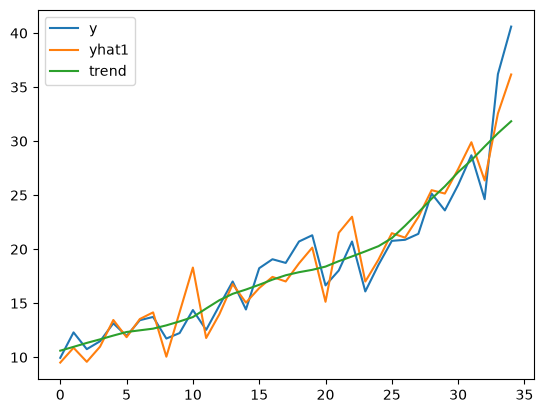

In [63]:

forecast_np[['y','yhat1', 'trend']].plot()

In [64]:
!pip install plotly-resampler

In [65]:
!pip install anywidget

In [66]:
model.plot_components

<bound method NeuralProphet.plot_components of <neuralprophet.forecaster.NeuralProphet object at 0x0000020A445C0B90>>

In [67]:
import anywidget

In [68]:
import matplotlib.pyplot as plt


In [69]:
fig = model.plot(forecast_np)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



In [70]:
type(fig)

plotly_resampler.figure_resampler.figurewidget_resampler.FigureWidgetResampler

In [71]:
fig.update_layout(
    title="Interactive 1M Point Resampled Chart",
    xaxis_title="Time / Index",
    yaxis_title="Value"
)

FigureWidgetResampler({
    'data': [{'fill': 'none',
              'line': {'color': 'rgba(45, 146, 255, 1.0)', 'width': 2},
              'mode': 'lines',
              'name': 'yhat1',
              'type': 'scatter',
              'uid': '1ddd1adc-c904-46ce-a08a-359419198253',
              'x': array([datetime.datetime(2023, 5, 1, 0, 0),
                          datetime.datetime(2023, 6, 1, 0, 0),
                          datetime.datetime(2023, 7, 3, 0, 0),
                          datetime.datetime(2023, 8, 1, 0, 0),
                          datetime.datetime(2023, 9, 1, 0, 0),
                          datetime.datetime(2023, 10, 2, 0, 0),
                          datetime.datetime(2023, 11, 1, 0, 0),
                          datetime.datetime(2023, 12, 1, 0, 0),
                          datetime.datetime(2024, 1, 2, 0, 0),
                          datetime.datetime(2024, 2, 1, 0, 0),
                          datetime.datetime(2024, 3, 1, 0, 0),
                      

In [72]:
fig

FigureWidgetResampler({
    'data': [{'fill': 'none',
              'line': {'color': 'rgba(45, 146, 255, 1.0)', 'width': 2},
              'mode': 'lines',
              'name': 'yhat1',
              'type': 'scatter',
              'uid': '1ddd1adc-c904-46ce-a08a-359419198253',
              'x': array([datetime.datetime(2023, 5, 1, 0, 0),
                          datetime.datetime(2023, 6, 1, 0, 0),
                          datetime.datetime(2023, 7, 3, 0, 0),
                          datetime.datetime(2023, 8, 1, 0, 0),
                          datetime.datetime(2023, 9, 1, 0, 0),
                          datetime.datetime(2023, 10, 2, 0, 0),
                          datetime.datetime(2023, 11, 1, 0, 0),
                          datetime.datetime(2023, 12, 1, 0, 0),
                          datetime.datetime(2024, 1, 2, 0, 0),
                          datetime.datetime(2024, 2, 1, 0, 0),
                          datetime.datetime(2024, 3, 1, 0, 0),
                      

In [73]:
forecast_np

,ds,y,yhat1,trend,season_yearly
0,2023-05-01,9.946,9.505976,10.609550,-1.103575
1,2023-06-01,12.300,10.878934,10.962595,-0.083661
2,2023-07-03,10.750,9.577673,11.327028,-1.749354
3,2023-08-01,11.480,10.980247,11.656108,-0.675861
4,2023-09-01,13.140,13.449049,12.006943,1.442105
5,2023-10-02,11.970,11.855036,12.337399,-0.482363
6,2023-11-01,13.430,13.538452,12.492153,1.046299
7,2023-12-01,13.730,14.152688,12.646908,1.505781
8,2024-01-02,11.730,10.051557,12.951727,-2.900170
9,2024-02-01,12.240,14.173210,13.316485,0.856724


In [74]:
future = model.make_future_dataframe( data, periods=12)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [71.429]% of the data.
WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternati

In [75]:
future

,ds,y
0,2026-04-01,None
1,2026-05-01,None
2,2026-06-01,None
3,2026-07-01,None
4,2026-08-01,None
5,2026-09-01,None
6,2026-10-01,None
7,2026-11-01,None
8,2026-12-01,None
9,2027-01-01,None


In [76]:
forecast = model.predict(future)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

INFO - (NP.df_utils._infer_frequency) - Major frequency MS corresponds to [91.667]% of the data.
WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternative to change the dtype.
  converted_ds = pd.to_datetime(ds_col, utc=True).view(dtype=np.int64)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\df_utils.py:1152: FutureWarning: Series.view is deprecated and will be removed in a future version. Use ``astype`` as an alternati

Predicting: |          | 0/? [00:00<?, ?it/s]

INFO - (NP.df_utils.return_df_in_original_format) - Returning df with no ID column


In [77]:
forecast

,ds,y,yhat1,trend,season_yearly
0,2026-04-01,None,30.177990,33.027809,-2.849816
1,2026-05-01,None,33.049320,34.216351,-1.167032
2,2026-06-01,None,35.451176,35.444504,0.006671
3,2026-07-01,None,35.637238,36.633049,-0.995809
4,2026-08-01,None,37.308933,37.861198,-0.552265
5,2026-09-01,None,40.424084,39.089352,1.334733
6,2026-10-01,None,39.518154,40.277897,-0.759739
7,2026-11-01,None,42.475304,41.506050,0.969254
8,2026-12-01,None,44.279457,42.694592,1.584867
9,2027-01-01,None,41.388165,43.922741,-2.534578


In [78]:
model.plot(forecast)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:98: FutureWarning: Downcasting object dtype arrays on .fillna, .ffill, .bfill is deprecated and will change in a future version. Call result.infer_objects(copy=False) instead. To opt-in to the future behavior, set `pd.set_option('future.no_silent_downcasting', True)`
  fcst = fcst.fillna(value=np.nan)

WARNING - (py.warnings._showwarnmsg) - C:\Users\ftorr\anaconda3\envs\myenv\Lib\site-packages\neuralprophet\plot_forecast_plotly.py:100: FutureWarning: The behavior of DatetimeProperties.to_pydatetime is deprecated, in a future version this will return a Series containing python datetime objects instead of an ndarray. To retain the old behavior, call `np.array` on the result
  ds = fcst["ds"].dt.to_pydatetime()



FigureWidgetResampler({
    'data': [{'fill': 'none',
              'line': {'color': 'rgba(45, 146, 255, 1.0)', 'width': 2},
              'mode': 'lines',
              'name': 'yhat1',
              'type': 'scatter',
              'uid': '34c93cf5-1a4d-4df1-a909-071cc01a1f05',
              'x': array([datetime.datetime(2026, 4, 1, 0, 0),
                          datetime.datetime(2026, 5, 1, 0, 0),
                          datetime.datetime(2026, 6, 1, 0, 0),
                          datetime.datetime(2026, 7, 1, 0, 0),
                          datetime.datetime(2026, 8, 1, 0, 0),
                          datetime.datetime(2026, 9, 1, 0, 0),
                          datetime.datetime(2026, 10, 1, 0, 0),
                          datetime.datetime(2026, 11, 1, 0, 0),
                          datetime.datetime(2026, 12, 1, 0, 0),
                          datetime.datetime(2027, 1, 1, 0, 0),
                          datetime.datetime(2027, 2, 1, 0, 0),
                      

In [79]:
# Save to CSV
finalNew.to_csv('finalNew.csv', index=False)